# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

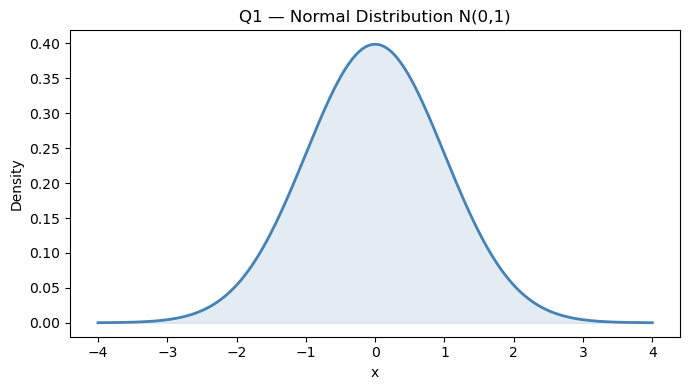

Scored above 85: 7.50%


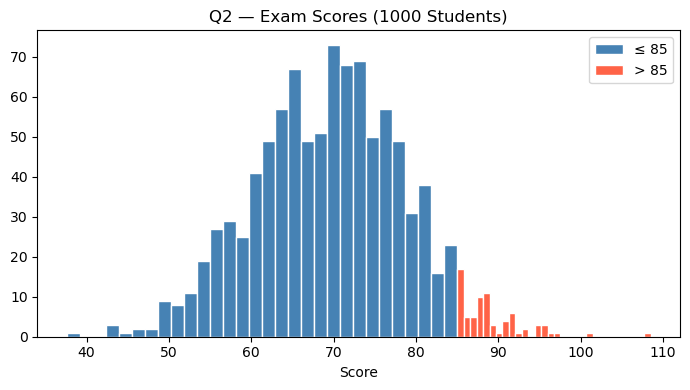

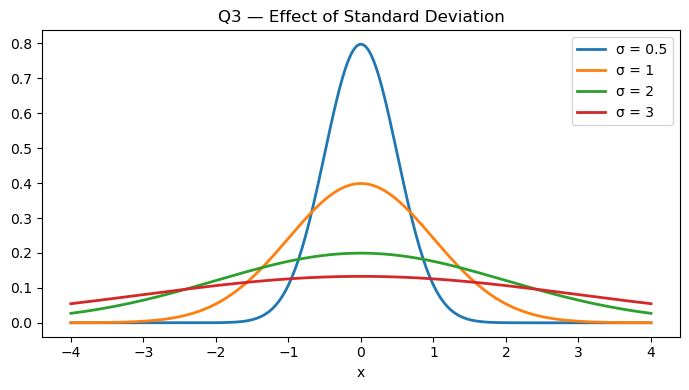

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Q1: Plot Normal Distribution

x = np.linspace(-4, 4, 300)
plt.figure(figsize=(7, 4))
plt.plot(x, norm.pdf(x, 0, 1), color='steelblue', linewidth=2)
plt.fill_between(x, norm.pdf(x, 0, 1), alpha=0.15, color='steelblue')
plt.title('Q1 — Normal Distribution N(0,1)')
plt.xlabel('x') ; plt.ylabel('Density')
plt.tight_layout() ; plt.show()



# Q2: Exam Scores % above 85 
np.random.seed(42)
scores = np.random.normal(70, 10, 1000)
pct = np.sum(scores > 85) / 1000 * 100
print(f"Scored above 85: {pct:.2f}%")

plt.figure(figsize=(7, 4))
plt.hist(scores[scores <= 85], bins=30, color='steelblue', edgecolor='white', label='≤ 85')
plt.hist(scores[scores  > 85], bins=30, color='tomato',    edgecolor='white', label='> 85')
plt.title('Q2 — Exam Scores (1000 Students)') ; plt.xlabel('Score')
plt.legend() ; plt.tight_layout() ; plt.show()


# Q3: how changingStd Effect the spread  

plt.figure(figsize=(7, 4))
for std, color in zip([0.5, 1, 2, 3], ['tomato','steelblue','seagreen','purple']):
    plt.plot(x, norm.pdf(x, 0, std), linewidth=2, label=f'σ = {std}')
plt.title('Q3 — Effect of Standard Deviation')
plt.xlabel('x') ; plt.legend() ; plt.tight_layout() ; plt.show()

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

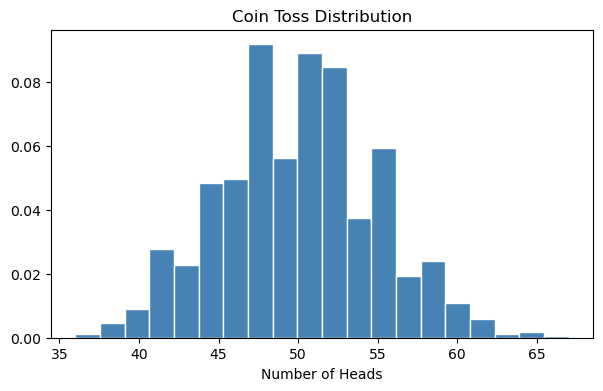

P(6 correct out of 10) = 0.0162


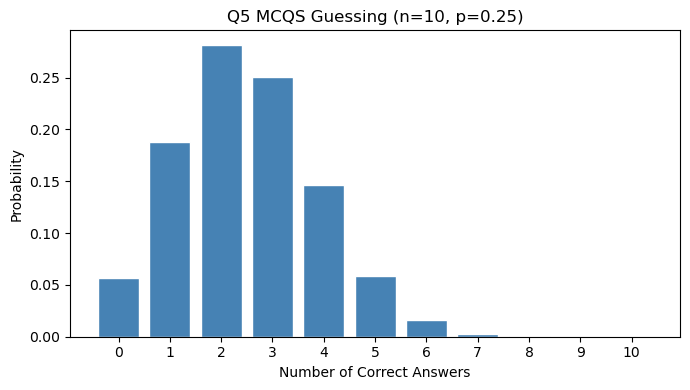

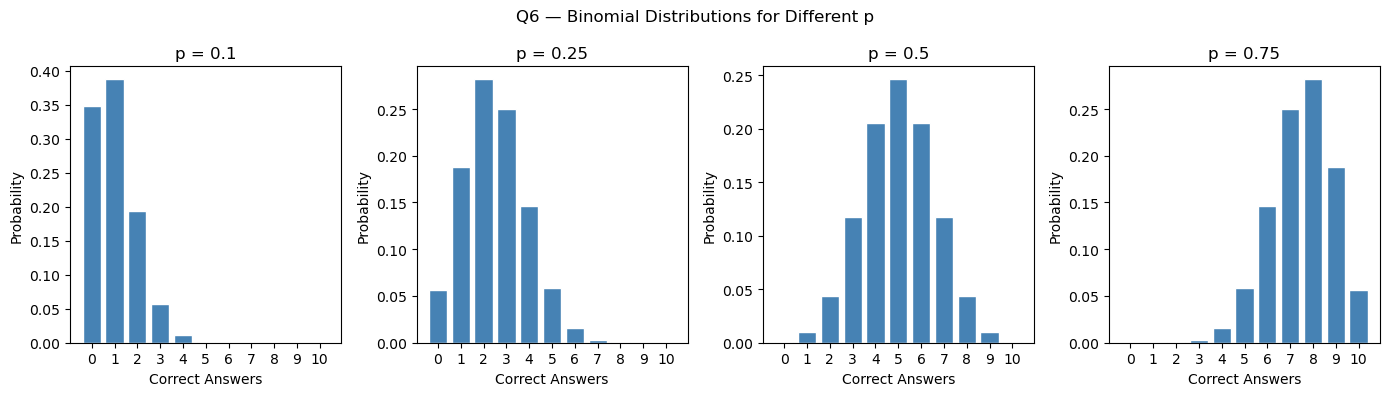

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, binom

# Q4 
np.random.seed(42)
results = np.random.binomial(n=100, p=0.5, size=1000)
plt.figure(figsize=(7, 4))
plt.title('Coin Toss Distribution')
plt.hist(results, bins=20, color='steelblue', edgecolor='white', density=True)
plt.xlabel('Number of Heads')
plt.show()



# Q5
prob = binom.pmf(k=6, n=10, p=0.25)
print(f"P(6 correct out of 10) = {prob:.4f}")
k = np.arange(0, 11)
plt.figure(figsize=(7, 4))
plt.bar(k, binom.pmf(k, 10, 0.25), color='steelblue', edgecolor='white')
plt.title('Q5 MCQS Guessing (n=10, p=0.25)')
plt.xlabel('Number of Correct Answers')
plt.ylabel('Probability')
plt.xticks(k) ; plt.tight_layout()
plt.show()



#Q6 

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, p in zip(axes, [0.1, 0.25, 0.5, 0.75]):
    k = np.arange(0, 11)
    ax.bar(k, binom.pmf(k, 10, p), color='steelblue', edgecolor='white')
    ax.set_title(f'p = {p}')
    ax.set_xlabel('Correct Answers')
    ax.set_ylabel('Probability')
    ax.set_xticks(k)
plt.suptitle('Q6 — Binomial Distributions for Different p')
plt.tight_layout() ; plt.show()




## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

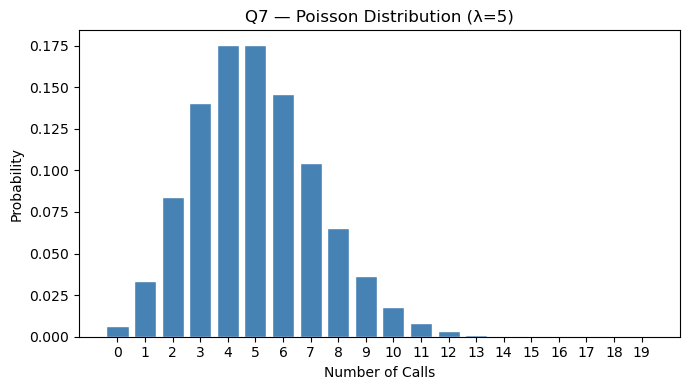

P(exactly 3 calls) = 0.1404


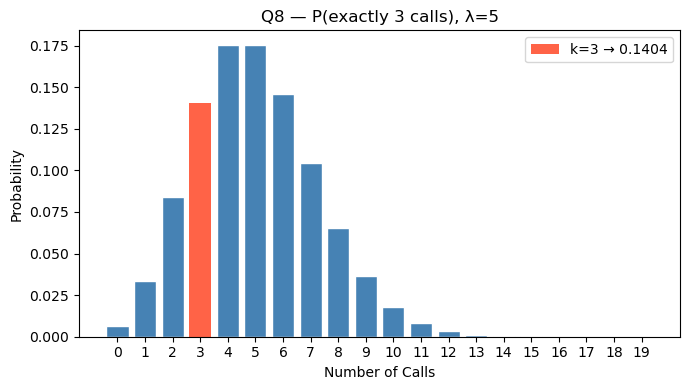

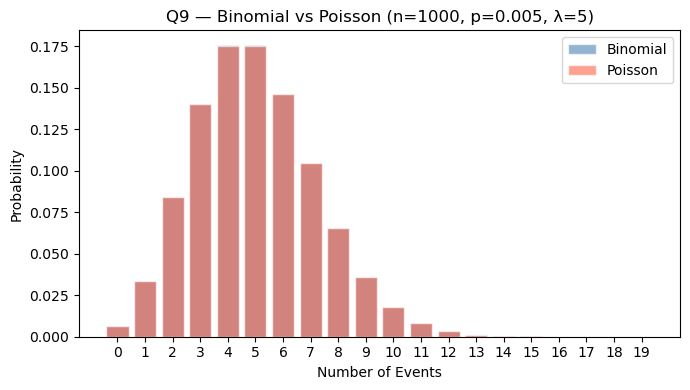

Binomial mean: 5.0
Poisson mean: 5
Difference at k=3: 7.1e-05


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import poisson, binom

# Q7 
k= np.arange(0, 20)
plt.figure(figsize=(7, 4))
plt.bar(k, poisson.pmf(k, mu=5), color='steelblue', edgecolor='white')
plt.title('Q7 — Poisson Distribution (λ=5)')
plt.xlabel('Number of Calls') ; plt.ylabel('Probability')
plt.xticks(k) ; plt.tight_layout() ; plt.show()

# Q8

prob = poisson.pmf(k=3, mu=5)
print(f"P(exactly 3 calls) = {prob:.4f}") 

plt.figure(figsize=(7, 4))
plt.bar(k, poisson.pmf(k, mu=5), color='steelblue', edgecolor='white')
plt.bar(3, poisson.pmf(3, mu=5), color='tomato', label=f'k=3 → {prob:.4f}')
plt.title('Q8 — P(exactly 3 calls), λ=5')
plt.xlabel('Number of Calls')
plt.ylabel('Probability')
plt.xticks(k)
plt.legend()
plt.tight_layout() 
plt.show()

# Q9 
n, p, lam = 1000, 0.005, 5
k_values = np.arange(0, 20)
plt.figure(figsize=(7, 4))
plt.bar(k_values, binom.pmf(k_values, n, p), color='steelblue', edgecolor='white', alpha=0.6, label='Binomial')
plt.bar(k_values, poisson.pmf(k_values, lam), color='tomato', edgecolor='white', alpha=0.6, label='Poisson')
plt.title('Q9 — Binomial vs Poisson (n=1000, p=0.005, λ=5)')
plt.xlabel('Number of Events') ; plt.ylabel('Probability')
plt.xticks(k_values) ; plt.legend() ; plt.tight_layout() ; plt.show()   
print("Binomial mean:", round(n*p, 2))
print("Poisson mean:", round(lam, 2))
print("Difference at k=3:", round(abs(binom.pmf(3, n, p) - poisson.pmf(3, lam)), 6))


## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


In [ ]:
# Your code here


## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [ ]:
# Your code here


## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


In [ ]:
# Your code here


## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


In [ ]:
# Your code here
